## Data Preparation

Decisions:

- Keep `f0`-`f11` as the pre-treatment feature set.
- Use no additional feature engineering, feature selection, scaling, or imputation.
- Keep `treatment` as the treatment indicator, separate from the feature matrix.
- Drop `exposure` because it is observed after treatment and has leakage risk.
- Keep `visit` and `conversion` as outcomes.

Notebook responsibility:

1. Complete Criteo-specific data understanding and EDA.
2. Apply the data decisions above.
3. Save one modeling-ready prepared dataset containing:
   - `f0`-`f11`
   - `treatment`
   - `visit`
   - `conversion`

The notebook stops at the prepared-dataset boundary.

The framework is responsible for:

1. validating the prepared dataset contract;
2. creating the internal `row_id`;
3. assigning deterministic train / validation / test splits;
4. creating outcome-specific standardized datasets;
5. training and evaluating the configured models.

## Setup

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd


In [2]:
PROJECT_ROOT = next(
    path
    for path in (Path.cwd(), *Path.cwd().parents)
    if (
        path
        / "configs"
        / "datasets"
        / "criteo.yaml"
    ).exists()
)

SRC_PATH = PROJECT_ROOT / "src"

if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

PROJECT_ROOT

WindowsPath('d:/thao/d/uplif_model/uplif_customer_selection')

In [3]:
from uplift_modeling.data.dataset_spec import (
    load_dataset_config,
)
from uplift_modeling.data.validation import (
    validate_prepared_dataset_contract,
)


In [4]:
dataset_config_path = (
    PROJECT_ROOT
    / "configs"
    / "datasets"
    / "criteo.yaml"
)

dataset_config = load_dataset_config(
    dataset_config_path,
    project_root=PROJECT_ROOT,
)

dataset_spec = dataset_config.spec
feature_columns = list(dataset_spec.feature_columns)
outcome_columns = list(dataset_spec.outcome_columns)

dataset_config


DatasetConfig(spec=DatasetSpec(name='criteo', treatment_column='treatment', split_column='split', feature_columns=('f0', 'f1', 'f2', 'f3', 'f4', 'f5', 'f6', 'f7', 'f8', 'f9', 'f10', 'f11'), outcome_columns=('visit', 'conversion'), entity_id_column=None), prepared_path=WindowsPath('D:/thao/d/uplif_model/uplif_customer_selection/data/interim/criteo/criteo_modeling_base.parquet'), processed_paths={'visit': WindowsPath('D:/thao/d/uplif_model/uplif_customer_selection/data/processed/criteo/criteo_decision_visit.parquet'), 'conversion': WindowsPath('D:/thao/d/uplif_model/uplif_customer_selection/data/processed/criteo/criteo_decision_conversion.parquet')}, split=SplitConfig(assign_if_missing=True, train_size=0.6, validation_size=0.2, test_size=0.2, random_state=42))

In [5]:
DATA_PATH_OVERRIDE: str | None = None


LOCAL_RAW_DIR = (PROJECT_ROOT/ "data"/ "raw"/ "criteo")


if DATA_PATH_OVERRIDE is not None:
    data_path = Path(DATA_PATH_OVERRIDE).expanduser()

else:
    local_candidates = [
        LOCAL_RAW_DIR/ "criteo-research-uplift-v2.1.csv.gz",

        LOCAL_RAW_DIR/ "criteo-uplift-v2.1.csv",
    ]

    data_path = next((path for path in local_candidates if path.exists()),
        None,
    )

    if data_path is None:
        kaggle_input = Path("/kaggle/input")

        if kaggle_input.exists():
            kaggle_candidates = []

            for filename in (
                "criteo-uplift-v2.1.csv",
                "criteo-research-uplift-v2.1.csv.gz",
            ):
                kaggle_candidates.extend(kaggle_input.rglob(filename))

            if kaggle_candidates:
                data_path = sorted(kaggle_candidates)[0]

if data_path is None or not data_path.exists():
    raise FileNotFoundError(
        "Criteo raw dataset not found locally "
        "or under /kaggle/input."
    )

print("Criteo raw dataset:", data_path)

data_path

Criteo raw dataset: d:\thao\d\uplif_model\uplif_customer_selection\data\raw\criteo\criteo-research-uplift-v2.1.csv.gz


WindowsPath('d:/thao/d/uplif_model/uplif_customer_selection/data/raw/criteo/criteo-research-uplift-v2.1.csv.gz')

In [6]:
df = pd.read_csv(data_path)

df.head()

,f0,f1,f2,f3,f4,f5,f6,f7,f8,f9,f10,f11,treatment,conversion,visit,exposure
0,12.616365,10.059654,8.976429,4.679882,10.280525,4.115453,0.294443,4.833815,3.955396,13.190056,5.300375,-0.168679,1,0,0,0
1,12.616365,10.059654,9.002689,4.679882,10.280525,4.115453,0.294443,4.833815,3.955396,13.190056,5.300375,-0.168679,1,0,0,0
2,12.616365,10.059654,8.964775,4.679882,10.280525,4.115453,0.294443,4.833815,3.955396,13.190056,5.300375,-0.168679,1,0,0,0
3,12.616365,10.059654,9.002801,4.679882,10.280525,4.115453,0.294443,4.833815,3.955396,13.190056,5.300375,-0.168679,1,0,0,0
4,12.616365,10.059654,9.037999,4.679882,10.280525,4.115453,0.294443,4.833815,3.955396,13.190056,5.300375,-0.168679,1,0,0,0


In [7]:
column_roles = pd.Series(
    {
        **{
            column: "pre_treatment_feature"
            for column in feature_columns
        },
        "treatment": "treatment_indicator",
        "conversion": "outcome_label",
        "visit": "outcome_label",
        "exposure": "post_treatment_exposure",
    },
    name="role",
).to_frame()

column_roles


,role
f0,pre_treatment_feature
f1,pre_treatment_feature
f2,pre_treatment_feature
f3,pre_treatment_feature
f4,pre_treatment_feature
f5,pre_treatment_feature
f6,pre_treatment_feature
f7,pre_treatment_feature
f8,pre_treatment_feature
f9,pre_treatment_feature


In [8]:
raw_data_overview = pd.Series(
    {
        "row_count": len(df),
        "column_count": df.shape[1],
        "duplicate_rows": int(df.duplicated().sum()),
        "columns_with_nulls": int(df.isna().any().sum()),
    },
    name="value",
)

raw_data_overview


row_count             13979592
column_count                16
duplicate_rows         1259545
columns_with_nulls           0
Name: value, dtype: int64

In [9]:
pd.Series(
    {
        "features": feature_columns,
        "treatment": dataset_spec.treatment_column,
        "outcomes": outcome_columns,
        "excluded_from_modeling": ["exposure"],
    },
    name="value",
)


features                  [f0, f1, f2, f3, f4, f5, f6, f7, f8, f9, f10, ...
treatment                                                         treatment
outcomes                                                [visit, conversion]
excluded_from_modeling                                           [exposure]
Name: value, dtype: object

## Data Understanding


In [10]:
df.head(5)

,f0,f1,f2,f3,f4,f5,f6,f7,f8,f9,f10,f11,treatment,conversion,visit,exposure
0,12.616365,10.059654,8.976429,4.679882,10.280525,4.115453,0.294443,4.833815,3.955396,13.190056,5.300375,-0.168679,1,0,0,0
1,12.616365,10.059654,9.002689,4.679882,10.280525,4.115453,0.294443,4.833815,3.955396,13.190056,5.300375,-0.168679,1,0,0,0
2,12.616365,10.059654,8.964775,4.679882,10.280525,4.115453,0.294443,4.833815,3.955396,13.190056,5.300375,-0.168679,1,0,0,0
3,12.616365,10.059654,9.002801,4.679882,10.280525,4.115453,0.294443,4.833815,3.955396,13.190056,5.300375,-0.168679,1,0,0,0
4,12.616365,10.059654,9.037999,4.679882,10.280525,4.115453,0.294443,4.833815,3.955396,13.190056,5.300375,-0.168679,1,0,0,0


In [11]:
memory_usage_mb = df.memory_usage(index=True, deep=True).sum() / 1024**2

pd.Series(
    {
        "row_count": len(df),
        "column_count": df.shape[1],
        "memory_usage_mb": memory_usage_mb,
    },
    name="value",
)


row_count          1.397959e+07
column_count       1.600000e+01
memory_usage_mb    1.706493e+03
Name: value, dtype: float64

### Treatment Population

In [12]:
treatment_summary = pd.DataFrame(
    {
        "row_count": df["treatment"].value_counts().sort_index(),
        "population_share": df["treatment"]
        .value_counts(normalize=True)
        .sort_index(),
    }
)

treatment_summary.index.name = "treatment"
treatment_summary

,row_count,population_share
treatment,,
0,2096937,0.15
1,11882655,0.85


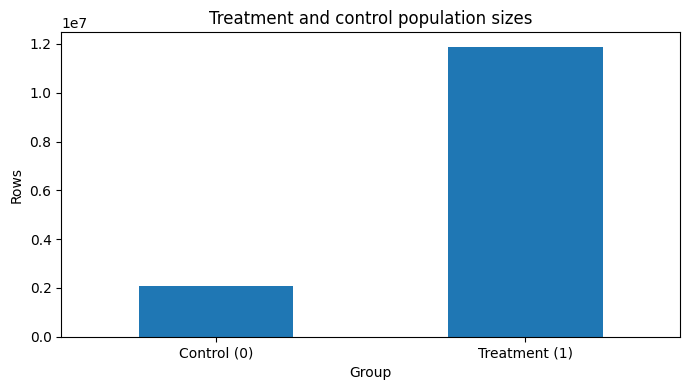

In [13]:
treatment_plot_data = treatment_summary.rename(
    index={0: "Control (0)", 1: "Treatment (1)"}
)

treatment_axis = treatment_plot_data["row_count"].plot(
    kind="bar",
    figsize=(7, 4),
    title="Treatment and control population sizes",
    rot=0,
)
treatment_axis.set_xlabel("Group")
treatment_axis.set_ylabel("Rows")
treatment_axis.set_xticklabels(
    treatment_plot_data.index,
    rotation=0,
    ha="center",
)
plt.tight_layout()
plt.show()

### Outcome Rates by Treatment

In [14]:
outcome_columns = list(dataset_spec.outcome_columns)

outcome_rate_by_treatment = df.groupby("treatment")[
    outcome_columns
].mean()

outcome_rate_by_treatment


,visit,conversion
treatment,,
0,0.038201,0.001938
1,0.048543,0.003089


In [15]:
outcome_difference_rows = []

for outcome_column in outcome_columns:
    control_rate = outcome_rate_by_treatment.loc[0, outcome_column]
    treated_rate = outcome_rate_by_treatment.loc[1, outcome_column]
    absolute_difference = treated_rate - control_rate
    relative_difference = (
        absolute_difference / control_rate
        if control_rate != 0
        else pd.NA
    )

    outcome_difference_rows.append(
        {
            "outcome": outcome_column,
            "control_rate": control_rate,
            "treated_rate": treated_rate,
            "absolute_difference": absolute_difference,
            "relative_difference": relative_difference,
            "positive_count": int(df[outcome_column].sum()),
            "positive_rate": df[outcome_column].mean(),
        }
    )

outcome_difference_report = pd.DataFrame(outcome_difference_rows)
outcome_difference_report

,outcome,control_rate,treated_rate,absolute_difference,relative_difference,positive_count,positive_rate
0,visit,0.038201,0.048543,0.010342,0.270737,656929,0.046992
1,conversion,0.001938,0.003089,0.001152,0.594488,40774,0.002917


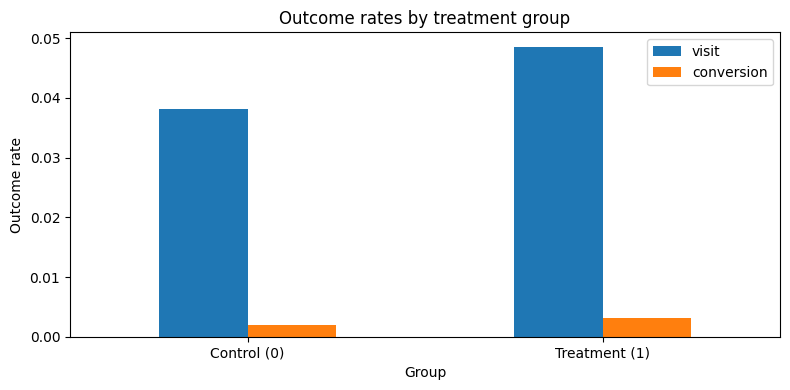

In [16]:
outcome_plot_data = outcome_rate_by_treatment.rename(
    index={0: "Control (0)", 1: "Treatment (1)"}
)

outcome_axis = outcome_plot_data.plot(
    kind="bar",
    figsize=(8, 4),
    title="Outcome rates by treatment group",
    rot=0,
)
outcome_axis.set_xlabel("Group")
outcome_axis.set_ylabel("Outcome rate")
outcome_axis.set_xticklabels(
    outcome_plot_data.index,
    rotation=0,
    ha="center",
)
plt.tight_layout()
plt.show()

In [17]:
visit_conversion_table = pd.crosstab(
    df["visit"],
    df["conversion"],
    margins=True,
)

visit_conversion_table

conversion,0,1,All
visit,,,
0,13322663,0,13322663
1,616155,40774,656929
All,13938818,40774,13979592


In [19]:
conversion_given_visit = (
    df.loc[df["visit"] == 1, "conversion"].mean()
)

print(
    "P(conversion=1 | visit=1):",
    f"{conversion_given_visit:.4%}",
)

P(conversion=1 | visit=1): 6.2068%


### Exposure Analysis

`exposure` is analyzed separately because it is observed after treatment delivery. It should not be used as a pre-treatment feature for later uplift models.

In [20]:
exposure_summary = df.groupby("treatment")["exposure"].agg(
    row_count="count",
    exposed_count="sum",
    exposure_rate="mean",
)

exposure_summary

,row_count,exposed_count,exposure_rate
treatment,,,
0,2096937,0,0.000000
1,11882655,428212,0.036037


In [21]:
exposure_outcome_summary = df.groupby(
    ["treatment", "exposure"]
)[outcome_columns].agg(["count", "mean"])

exposure_outcome_summary

visit           conversion          
                       count      mean      count      mean
treatment exposure                                         
0         0          2096937  0.038201    2096937  0.001938
1         0         11454443  0.034861   11454443  0.001194
          1           428212  0.414538     428212  0.053784

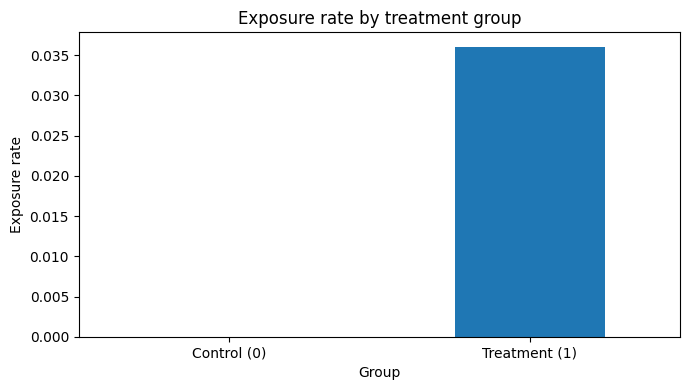

In [22]:
exposure_plot_data = exposure_summary.rename(
    index={0: "Control (0)", 1: "Treatment (1)"}
)

exposure_axis = exposure_plot_data["exposure_rate"].plot(
    kind="bar",
    figsize=(7, 4),
    title="Exposure rate by treatment group",
    rot=0,
)
exposure_axis.set_xlabel("Group")
exposure_axis.set_ylabel("Exposure rate")
exposure_axis.set_xticklabels(
    exposure_plot_data.index,
    rotation=0,
    ha="center",
)
plt.tight_layout()
plt.show()

### Feature Distributions

In [23]:
feature_summary = df[feature_columns].describe().T
feature_summary


,count,mean,std,min,25%,50%,75%,max
f0,13979592.0,19.620297,5.377464,12.616365,12.616365,21.923413,24.436459,26.745255
f1,13979592.0,10.069977,0.104756,10.059654,10.059654,10.059654,10.059654,16.344187
f2,13979592.0,8.446582,0.299316,8.214383,8.214383,8.214383,8.723335,9.051962
f3,13979592.0,4.178923,1.336645,-8.398387,4.679882,4.679882,4.679882,4.679882
f4,13979592.0,10.338837,0.343308,10.280525,10.280525,10.280525,10.280525,21.123508
f5,13979592.0,4.028513,0.431097,-9.011892,4.115453,4.115453,4.115453,4.115453
f6,13979592.0,-4.155356,4.577914,-31.429784,-6.699321,-2.411115,0.294443,0.294443
f7,13979592.0,5.101765,1.205248,4.833815,4.833815,4.833815,4.833815,11.998401
f8,13979592.0,3.933581,0.056660,3.635107,3.910792,3.971858,3.971858,3.971858
f9,13979592.0,16.027638,7.018975,13.190056,13.190056,13.190056,13.190056,75.295017


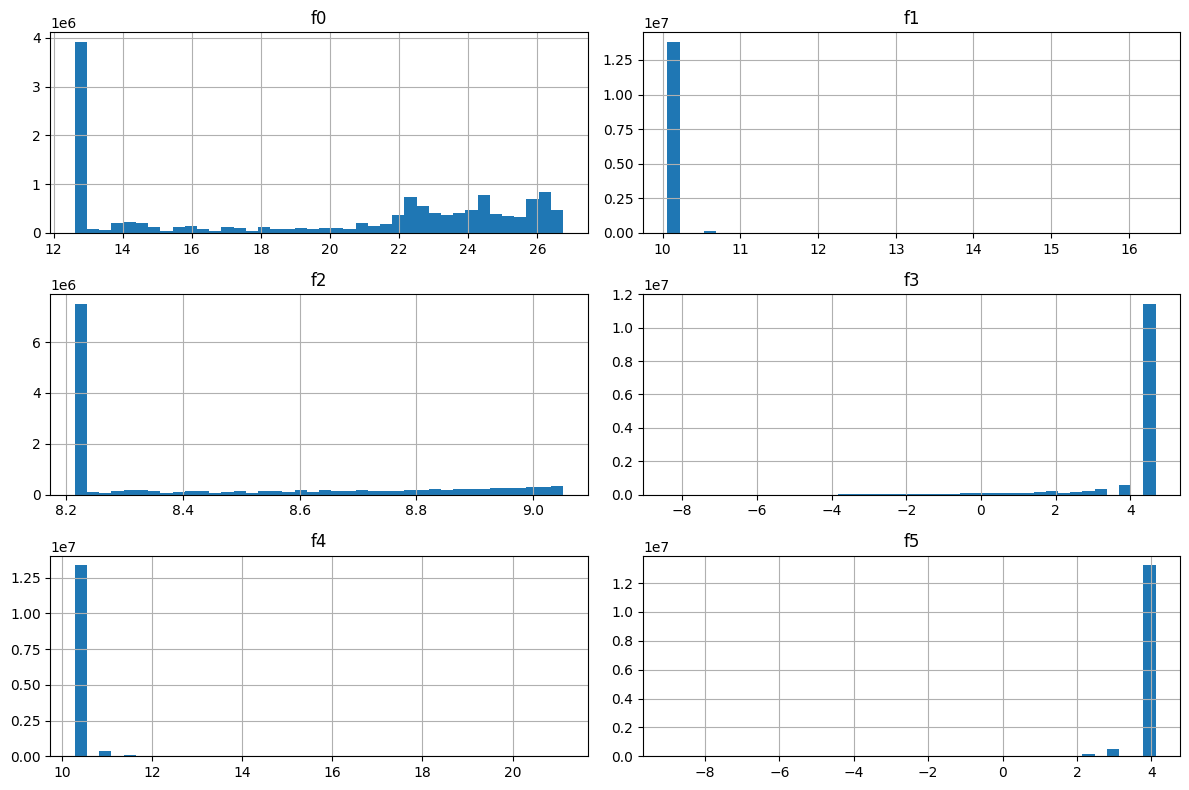

In [24]:
selected_feature_columns = feature_columns[:6]

df[selected_feature_columns].hist(
    bins=40,
    figsize=(12, 8),
)
plt.tight_layout()
plt.show()


### Feature Comparison by Treatment

In [25]:
feature_means_by_treatment = df.groupby("treatment")[
    feature_columns
].mean()

feature_mean_difference = (
    feature_means_by_treatment.loc[1]
    - feature_means_by_treatment.loc[0]
)

feature_comparison = pd.DataFrame(
    {
        "control_mean": feature_means_by_treatment.loc[0],
        "treated_mean": feature_means_by_treatment.loc[1],
        "absolute_mean_difference": feature_mean_difference,
    }
).sort_values(
    "absolute_mean_difference",
    key=lambda series: series.abs(),
    ascending=False,
)

feature_comparison


,control_mean,treated_mean,absolute_mean_difference
f6,-3.999880,-4.182792,-0.182913
f9,15.886253,16.052589,0.166336
f3,4.232821,4.169412,-0.063409
f0,19.651705,19.614755,-0.036950
f7,5.080284,5.105555,0.025271
f5,4.039339,4.026602,-0.012736
f4,10.336526,10.339245,0.002720
f1,10.067935,10.070337,0.002401
f2,8.448173,8.446302,-0.001872
f10,5.331898,5.333660,0.001762


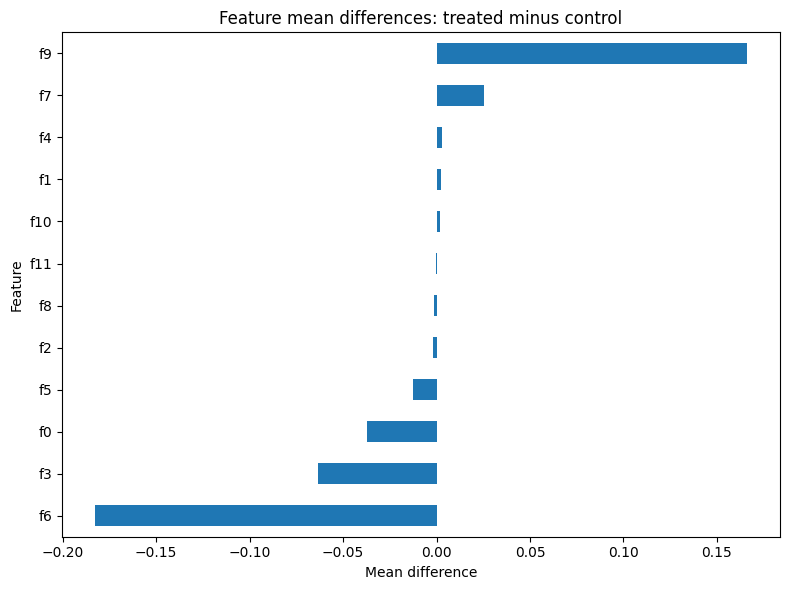

In [26]:
feature_comparison_axis = feature_comparison[
    "absolute_mean_difference"
].sort_values().plot(
    kind="barh",
    figsize=(8, 6),
    title="Feature mean differences: treated minus control",
)
feature_comparison_axis.set_xlabel("Mean difference")
feature_comparison_axis.set_ylabel("Feature")
plt.tight_layout()
plt.show()

## Prepared Modeling Table

Dataset-specific decisions:

- Keep `f0`–`f11` as pre-treatment features.
- Keep `treatment` as the treatment indicator.
- Keep `visit` and `conversion` as outcomes.
- Exclude `exposure` because it is post-treatment and would create leakage.
- No additional feature engineering, scaling, or imputation is applied here.

This notebook stops at the prepared modeling-table boundary.

The framework is responsible for:

- validating the prepared table against `DatasetConfig`;
- creating or preserving `row_id`;
- assigning train/validation/test splits when missing;
- creating one standardized decision dataset per outcome.

In [27]:
prepared_columns = [
    *feature_columns,
    dataset_spec.treatment_column,
    *outcome_columns,
]

prepared_df = df[prepared_columns].copy()

prepared_validation_report = validate_prepared_dataset_contract(
    prepared_df,
    dataset_spec,
    require_row_id=False,
)

prepared_path = dataset_config.prepared_path
prepared_path.parent.mkdir(
    parents=True,
    exist_ok=True,
)

prepared_df.to_parquet(
    prepared_path,
    index=False,
)

pd.Series(
    {
        "prepared_path": str(
            prepared_path.relative_to(PROJECT_ROOT)
        ),
        "row_count": len(prepared_df),
        "column_count": prepared_df.shape[1],
        "is_valid": prepared_validation_report["is_valid"],
        "columns": list(prepared_df.columns),
        "exposure_removed": "exposure" not in prepared_df.columns,
        "row_id_created_by_notebook": "row_id" in prepared_df.columns,
        "split_created_by_notebook": "split" in prepared_df.columns,
    },
    name="value",
)

prepared_path                  data\interim\criteo\criteo_modeling_base.parquet
row_count                                                              13979592
column_count                                                                 15
is_valid                                                                   True
columns                       [f0, f1, f2, f3, f4, f5, f6, f7, f8, f9, f10, ...
exposure_removed                                                           True
row_id_created_by_notebook                                                False
split_created_by_notebook                                                 False
Name: value, dtype: object